In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [7]:
pdf = sns.load_dataset("penguins")
pdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [9]:
pdf['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [10]:
pdf['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [11]:
pdf.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [13]:
pdf[pdf['bill_length_mm'].isna()]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [ ]:
# sns.load_dataset('penguins') 데이터셋을 이용하여

# 1. 기술 통계량
# 2. 결측치 확인 -> 인덱스 3, 339 삭제
# 3. 분포확인 ( 평균, 중앙값) -> species 분포 확인
# 4. 상관관계 -> 시각화, 수치로 확인 corr()
# 5. 결과해석

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000      -0.235053           0.656181   
bill_depth_mm           -0.235053       1.000000          -0.583851   
flipper_length_mm        0.656181      -0.583851           1.000000   
body_mass_g              0.595110      -0.471916           0.871202   

                   body_mass_g  
bill_length_mm        0.595110  
bill_depth_mm        -0.471916  
flipper_length_mm     0.871202  
body_mass_g           1.000000  


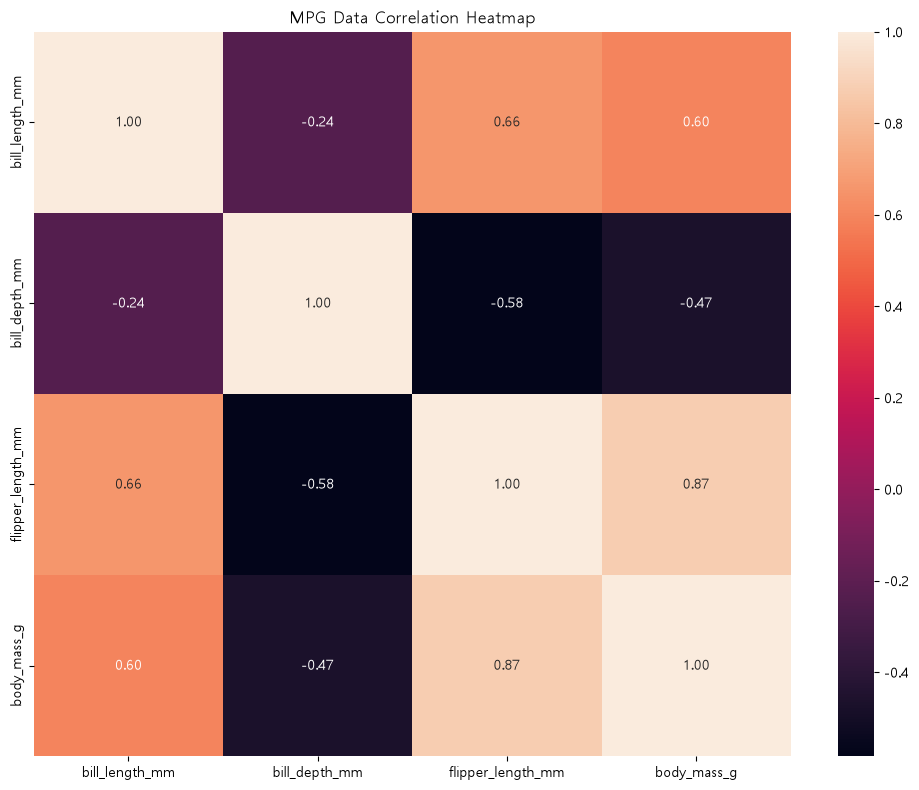

In [14]:

# 숫자형 변수들의 상관계수 계산
corr = pdf.corr(numeric_only=True)

# 상관계수 행렬 확인
print(corr)

# Figure 생성
fig = plt.figure(figsize=(10, 8))

# Figure 안에 1개의 Axes 생성
axes1 = fig.add_subplot(1, 1, 1)

# 상관계수 행렬을 Heatmap으로 표현
sns.heatmap(
    corr,
    annot=True,       # 각 칸에 상관계수 숫자 표시
    fmt=".2f",        # 소수점 둘째 자리까지 표시
    ax=axes1
)

# 제목 설정
axes1.set_title("MPG Data Correlation Heatmap")

# 그래프 여백 정리
fig.tight_layout()

# 그래프 출력
plt.show()

=== 1. 기술 통계량 ===
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000      13.100000         172.000000  2700.000000
25%         39.225000      15.600000         190.000000  3550.000000
50%         44.450000      17.300000         197.000000  4050.000000
75%         48.500000      18.700000         213.000000  4750.000000
max         59.600000      21.500000         231.000000  6300.000000


=== 2. 결측치 확인 및 인덱스 3, 339 삭제 ===
결측치 개수:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
인덱스 3, 339 삭제 후 데이터 크기: (342, 7)


=== 3. 분포 확인 (평균, 중앙값 및 species 분포) ===
[숫자형 변수 평균]
bill_length_mm         43.921930
bill_depth_mm  

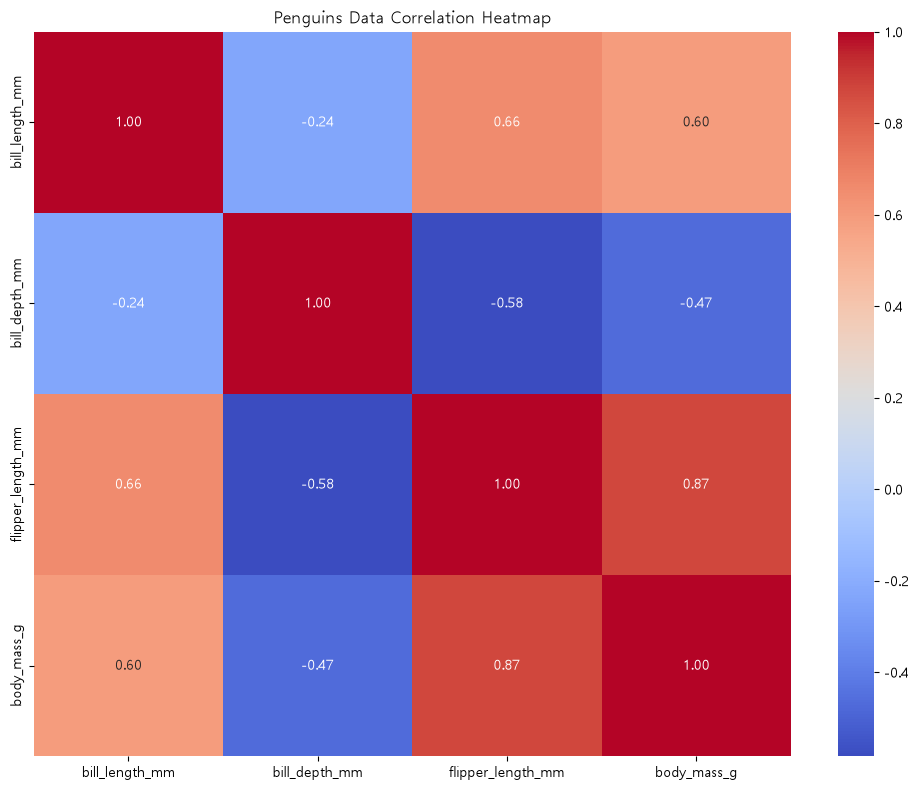

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 0. 데이터 불러오기
pdf = sns.load_dataset('penguins')

print('=== 1. 기술 통계량 ===')
print(pdf.describe())
print('\n' + '=' * 40 + '\n')

print('=== 2. 결측치 확인 및 인덱스 3, 339 삭제 ===')
print('결측치 개수:\n', pdf.isnull().sum())

# 지정된 인덱스(3, 339) 삭제 (존재하는 경우에만 안전하게 삭제)
drop_indices = [3, 339]
pdf = pdf.drop(
    index=[i for i in drop_indices if i in pdf.index], errors='ignore'
)
print(f'인덱스 3, 339 삭제 후 데이터 크기: {pdf.shape}\n')
print('=' * 40 + '\n')

print('=== 3. 분포 확인 (평균, 중앙값 및 species 분포) ===')
print('[숫자형 변수 평균]')
print(pdf.select_dtypes(include=['number']).mean(numeric_only=True))
print('\n[숫자형 변수 중앙값]')
print(pdf.select_dtypes(include=['number']).median(numeric_only=True))

print('\n[species(종) 분포 확인]')
print(pdf['species'].value_counts())
print('\n' + '=' * 40 + '\n')

print('=== 4. 상관관계 수치 확인 ===')
corr = pdf.corr(numeric_only=True)
print(corr)

# 상관관계 시각화 (Heatmap)
fig = plt.figure(figsize=(10, 8))
axes1 = fig.add_subplot(1, 1, 1)

sns.heatmap(
    corr,
    annot=True,  # 각 칸에 숫자 표시
    fmt='.2f',  # 소수점 둘째 자리
    cmap='coolwarm',  # 색상맵 설정
    ax=axes1,
)

# 제목을 펭귄 데이터셋에 맞게 수정
axes1.set_title('Penguins Data Correlation Heatmap')

fig.tight_layout()
plt.show()